
# 34763 — Autonomous Marine Robotics
##Introduction to MCAP Visualization

### In this exercise you will:

1. Install ROS 2/MCAP reading utilities and plotting libraries.  
2. Download a small MCAP example from Google Drive.
3. Read ROS2 messages from the MCAP file
4. Inspect the topics present in the recording.  
5. Plot a **timeline** of topic activity.  
6. Build a timestamp index to retrieve the **nearest** message by time.  
7. Decode **camera** images and **lidar** point clouds.  
8. Compose a **visual output** (6 cameras + top‑down lidar).
9. Experiment with the data in the MCAP file



## 1) Install dependencies
We install MCAP readers, ROS 2 support shims, visualization stacks, and OpenCV.

Note: Colab VMs reset on restart; re-run this cell if needed.


In [ ]:
!pip install mcap mcap-ros2-support rosbags matplotlib opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.9/137.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 9.1 MB/s eta 0:00:00


In [ ]:
import gdown
from mcap_ros2.reader import read_ros2_messages
import matplotlib.pyplot as plt
from bisect import bisect_left
import numpy as np
import struct
import cv2

## 2) Download the example MCAP file
The file is hosted on Google Drive. We download into the Colab working dir.


In [ ]:
url = 'https://drive.google.com/uc?id=14cSoBqrPkUakcu__dVtdQxPFUF0KgaH1'
gdown.download(url, "test.mcap", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=14cSoBqrPkUakcu__dVtdQxPFUF0KgaH1
From (redirected): https://drive.google.com/uc?id=14cSoBqrPkUakcu__dVtdQxPFUF0KgaH1&confirm=t&uuid=adc6f676-1ea4-4f3a-909b-d505153dcc6d
To: /content/test.mcap
100%|██████████| 243M/243M [00:02<00:00, 91.5MB/s]


'test.mcap'


## 3) Read ROS 2 messages from the MCAP file
We iterate the file once and collect all messages into a list.  
This is fine for small demos; for very large files, consider streaming.


In [ ]:
mcap_path = "/content/test.mcap"
messages = []

for msg in read_ros2_messages(mcap_path):
    messages.append(msg)

## 4) Inspect topics
Get a quick overview of all topics present in the recording.

In [ ]:
topics = set()

for msg in messages:
    topics.add(msg.channel.topic)

for topic in sorted(topics):
    print(topic)

/LWIR_port/image_raw
/LWIR_starboard/image_raw
/LWIR_stern/image_raw
/camera_0/image_raw
/camera_1/image_raw
/camera_2/image_raw
/capture_trigger
/ouster/imu
/ouster/points
/ouster/scan
/radar_data/b_scan_image
/rosout



## 5) Visualize a topic timeline
We plot when messages for each topic arrive (relative to the first timestamp).

This is helpful to see relative activity and synchronization at-a-glance.


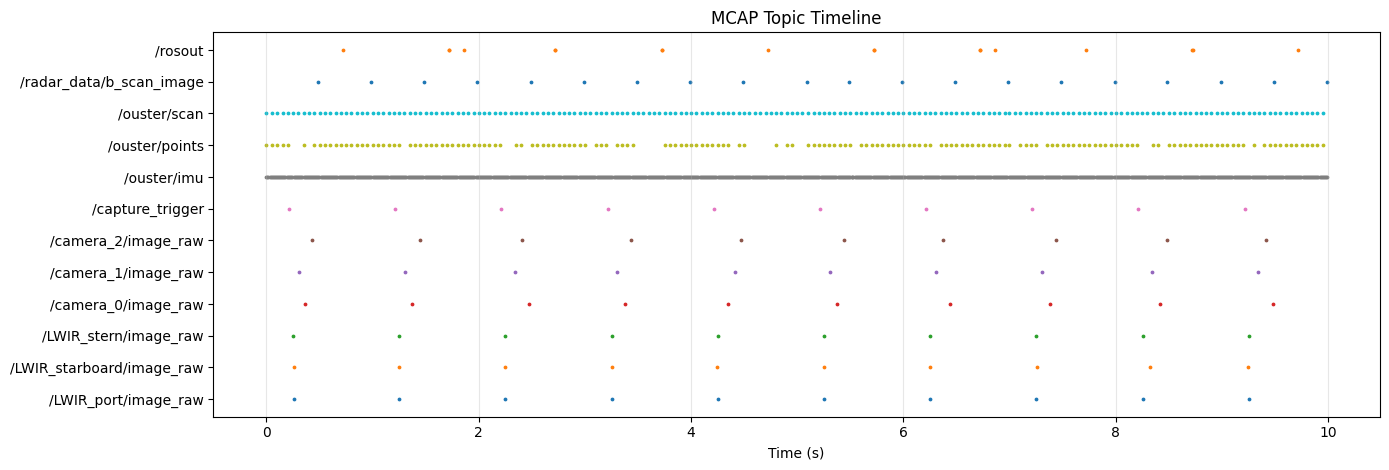

In [ ]:
topic_times = {}

for msg in messages:
    topic_times.setdefault(msg.channel.topic, []).append(msg.log_time.timestamp() )

t0 = min(t for times in topic_times.values() for t in times)

for topic in topic_times:
    topic_times[topic] = [t - t0 for t in topic_times[topic]]

fig, ax = plt.subplots(figsize=(14, max(4, 0.4 * len(topic_times))))

for i, (topic, times) in enumerate(sorted(topic_times.items())):
    ax.scatter(times, [i] * len(times), s=3)

ax.set_yticks(range(len(topic_times)))
ax.set_yticklabels(sorted(topic_times.keys()))
ax.set_xlabel("Time (s)")
ax.set_title("MCAP Topic Timeline")
ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 6) Build message timestamp index
Utility functions to:
- Build a per-topic sorted index of (timestamp, message).
- Retrieve the nearest message by a query timestamp using binary search.

These simplify synchronization between heterogeneous sensors.


In [ ]:
def index_messages(messages):
    """
    Build a per-topic time index for efficient nearest-neighbor timestamp lookup.

    Parameters
    ----------
    messages : list
        List of MCAP ROS 2 messages as yielded by `read_ros2_messages`, where
        each element has `.log_time.timestamp()` and `.channel.topic`.

    Returns
    -------
    dict[str, list[tuple[float, Any]]]
        A dictionary mapping topic -> list of (timestamp_seconds, message),
        sorted by timestamp ascending.
    """

    index = {}
    for msg in messages:
        t = msg.log_time.timestamp()
        index.setdefault(msg.channel.topic, []).append((t, msg))
    for topic in index:
        index[topic].sort(key=lambda x: x[0])
    return index

def get_nearest(topic_msgs, t):
    """
    Return the message in `topic_msgs` whose timestamp is nearest to `t`.

    Parameters
    ----------
    topic_msgs : list[tuple[float, Any]]
        Sorted list of (timestamp_seconds, message), typically from `index_messages()[topic]`.
    t : float
        Query timestamp (seconds).

    Returns
    -------
    Any
        The message with the closest timestamp to `t`.

    Notes
    -----
    Uses `bisect_left` for O(log N) search, then compares neighbors.
    """

    times = [x[0] for x in topic_msgs]
    i = bisect_left(times, t)
    if i == 0:
        return topic_msgs[0][1]
    if i == len(times):
        return topic_msgs[-1][1]
    before = topic_msgs[i - 1]
    after = topic_msgs[i]
    return before[1] if abs(before[0] - t) < abs(after[0] - t) else after[1]

msg_index = index_messages(messages)

## 7) Sensor decoding
Functions for:
- Converting ROS image messages to NumPy arrays.
# - Decoding a ROS `PointCloud2` (xyz as float32).
- Rendering a top-down lidar density view.
- Composing a dashboard frame (6 cameras + lidar).


In [ ]:
def ros_image_to_numpy(msg):
    """
    Convert a ROS image message to an HxWxC uint8 NumPy array (no color conversion).

    Parameters
    ----------
    msg : Any
        A message object where `msg.ros_msg` contains a ROS Image-like structure
        with fields: `data` (bytes), `height` (int), `width` (int).

    Returns
    -------
    np.ndarray
    """


    ros_img = msg.ros_msg
    img = np.frombuffer(ros_img.data, dtype=np.uint8)
    img = img.reshape(ros_img.height, ros_img.width, -1)
    return img


def decode_pointcloud(msg):
    """
    Decode a ROS `sensor_msgs/PointCloud2`-like message into XYZ float32 array.

    Parameters
    ----------
    msg : Any
        A message where `msg.ros_msg` is a PointCloud2-like object containing:
        - `fields` (with `.name`, `.offset`, `.datatype`)
        - `point_step` (int), `data` (bytes)

    Returns
    -------
    np.ndarray
        Array of shape (N, 3) containing [x, y, z] in meters (float32).
    """

    pc = msg.ros_msg

    # Build struct format from fields
    fmt = "<"  # little-endian
    offsets = {}
    for f in pc.fields:
        if f.datatype == 7:      # FLOAT32
            fmt += "f"
            offsets[f.name] = f.offset
        elif f.datatype == 2:    # UINT8
            fmt += "B"
            offsets[f.name] = f.offset

    step = pc.point_step
    data = pc.data

    points = []
    for i in range(0, len(data), step):
        x, y, z = struct.unpack_from("<fff", data, i)
        if not np.isnan(x):
            points.append([x, y, z])

    return np.asarray(points, dtype=np.float32)


def render_lidar_topdown(points, size=480, scale=10.0):
    """
    Render a simple top-down (x-y) lidar occupancy image from 3D points.

    Parameters
    ----------
    points : np.ndarray
        Array of shape (N, 3) with columns [x, y, z] in meters.
    size : int, optional
        Output image size (size x size), by default 480.
    scale : float, optional
        Radial extent in meters to include around the origin, by default 10.0.

    Returns
    -------
    np.ndarray
        RGB image (size x size x 3) with white pixels indicating point locations.
    """

    img = np.zeros((size, size, 3), dtype=np.uint8)

    pts = points[np.isfinite(points).all(axis=1)]
    pts = pts[np.linalg.norm(pts[:, :2], axis=1) < scale]

    x = (pts[:, 0] / scale * (size // 2) + size // 2).astype(int)
    y = (-pts[:, 1] / scale * (size // 2) + size // 2).astype(int)

    mask = (x >= 0) & (x < size) & (y >= 0) & (y < size)
    img[y[mask], x[mask]] = (255, 255, 255)

    return img


def compose_frame(cam_imgs, lidar_img):
    """
    Compose a dashboard frame from 6 camera images and one lidar top-down image.

    Parameters
    ----------
    cam_imgs : list[np.ndarray]
        List of 6 RGB images of identical shape (H, W, 3).
        Layout: first 3 go to the top row, next 3 to the bottom row.
    lidar_img : np.ndarray
        RGB lidar image to place to the right, resized to match dashboard height.

    Returns
    -------
    np.ndarray
        RGB composite image with cameras on the left and lidar on the right.

    Raises
    ------
    ValueError
        If `cam_imgs` does not contain exactly 6 images or shapes mismatch.
    """

    top = np.hstack(cam_imgs[:3])
    bottom = np.hstack(cam_imgs[3:])
    cams = np.vstack([top, bottom])

    lidar_img = cv2.resize(lidar_img, (cams.shape[1] // 2, cams.shape[0]))
    frame = np.hstack([cams, lidar_img])
    return frame

## 8) Visualize cameras and lidar
We:
1. Pick the a timestamp in the recording.
2. For each camera, grab the **nearest** frame to that time.
3. Grab the nearest lidar point cloud, render top-down.
4. Compose and display a combined dashboard.


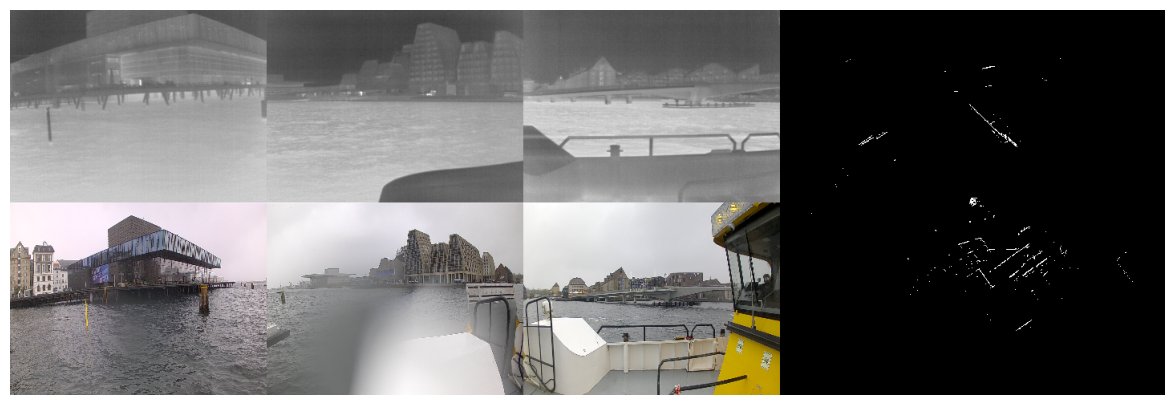

In [ ]:
# Select topics (and order of topics)
camera_topics = [
'/LWIR_stern/image_raw',
'/LWIR_port/image_raw',
'/LWIR_starboard/image_raw',
'/camera_2/image_raw',
'/camera_0/image_raw',
'/camera_1/image_raw',
]

lidar_topic = "/ouster/points"

# Select first timestamp in MCAP file
t_start = min(t for msgs in msg_index.values() for t, _ in msgs)

width, height = 320, 240

# Decode images
cam_imgs = []
for topic in camera_topics:
    msg = get_nearest(msg_index[topic], t_start)
    img = ros_image_to_numpy(msg)
    img = cv2.resize(img, (width, height))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    cam_imgs.append(img)

# Decode lidar points and generate image
lidar_msg = get_nearest(msg_index[lidar_topic], t_start)
points = decode_pointcloud(lidar_msg)
lidar_img = render_lidar_topdown(points, scale=200)

# Plot images
frame = compose_frame(cam_imgs, lidar_img)
fig, ax = plt.subplots(figsize=(18, 5))
ax.imshow(frame)
plt.axis('off')
plt.show()

## 9) Investigating the data
Spend some time understanding how to inspect the data and see what you can gather from the MCAP file

In [ ]:
## Add your code here